Exploring **AlexNet** architecture on the Tiny Images dataset over here

In [1]:
# import tensorflow as tf

# gpus = tf.config.list_physical_devices('GPU')

# for gpu in gpus:
#     tf.config.experimental.set_memory_growth(gpu, True)

# print("GPU:", gpus)

In [2]:
# !nvidia-smi

In [3]:
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf

2026-09-12 08:54:53.779220: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-09-12 08:54:53.779323: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-09-12 08:54:53.781663: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-09-12 08:54:53.791594: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-09-12 08:54:54.914040: W tensorflow/compiler/tf2

### Getting the TinyImages Dataset

In [4]:
from pathlib import Path

data_dir= Path("tiny-imagenet-200")
data_dir.exists()

True

In [5]:
list(data_dir.iterdir())

[PosixPath('tiny-imagenet-200/test'),
 PosixPath('tiny-imagenet-200/train'),
 PosixPath('tiny-imagenet-200/val'),
 PosixPath('tiny-imagenet-200/wnids.txt'),
 PosixPath('tiny-imagenet-200/words.txt')]

In [6]:
words= data_dir / "words.txt"
with open(words) as f:
    lines = f.readlines()

print(len(lines))

82115


That's 82115 classes in the WordNet dataset.. we're using a subset of that which is in the wnids.txt file

In [7]:
wnids= data_dir/"wnids.txt"

with open(wnids) as f: 
    lines= f.readlines()

print(len(lines))

200


Yeah.. so 200 classes in our ImageNet dataset

In [8]:

train_dir = data_dir / "train"
val_dir = data_dir / "val"
test_dir = data_dir / "test"

train_images = list(train_dir.glob("*/*/*.JPEG"))
val_images = list(val_dir.glob("*.JPEG"))
test_images = list(test_dir.glob("*.JPEG"))

print("Train:", len(train_images))
print("Val:", len(val_images))
print("Test:", len(test_images))

Train: 100000
Val: 0
Test: 0


TinyImages test set does not come with any labels.. so we're gonna be using our validation as our test set

In [9]:
train_images[:5]

[PosixPath('tiny-imagenet-200/train/n01443537/images/n01443537_0.JPEG'),
 PosixPath('tiny-imagenet-200/train/n01443537/images/n01443537_1.JPEG'),
 PosixPath('tiny-imagenet-200/train/n01443537/images/n01443537_10.JPEG'),
 PosixPath('tiny-imagenet-200/train/n01443537/images/n01443537_100.JPEG'),
 PosixPath('tiny-imagenet-200/train/n01443537/images/n01443537_101.JPEG')]

In [10]:
labels= [p.parent.parent.name for p in train_images[:5]]

In [11]:
labels

['n01443537', 'n01443537', 'n01443537', 'n01443537', 'n01443537']

In [12]:
val_images = list((val_dir / "images").glob("*.JPEG"))

In [13]:
len(val_images)

10000

In [14]:
val_annotations = val_dir / "val_annotations.txt"

print(val_annotations.exists())

with open(val_annotations) as f:
    for _ in range(5):
        print(f.readline().strip())

True
val_0.JPEG	n03444034	0	32	44	62
val_1.JPEG	n04067472	52	55	57	59
val_2.JPEG	n04070727	4	0	60	55
val_3.JPEG	n02808440	3	3	63	63
val_4.JPEG	n02808440	9	27	63	48


In [15]:
from sklearn.model_selection import train_test_split

# Labels for the 100k training images
train_labels = [p.parent.parent.name for p in train_images]

# Split 100k training images into 90k train + 10k validation
train_paths, valid_paths, train_labels, valid_labels = train_test_split(
    train_images,
    train_labels,
    test_size=0.1,
    stratify=train_labels, # make sure test set has equal distribution of images
    random_state= 42
)

# Official Tiny ImageNet validation set becomes our test set
test_paths = val_images
test_labels = []

with open(val_annotations) as f:
    for line in f:
        parts = line.strip().split()
        test_labels.append(parts[1])

print("Train:", len(train_paths))
print("Validation:", len(valid_paths))
print("Test:", len(test_paths))

Train: 90000
Validation: 10000
Test: 10000


In [16]:
train_paths[:5]

[PosixPath('tiny-imagenet-200/train/n04146614/images/n04146614_173.JPEG'),
 PosixPath('tiny-imagenet-200/train/n02233338/images/n02233338_413.JPEG'),
 PosixPath('tiny-imagenet-200/train/n03854065/images/n03854065_340.JPEG'),
 PosixPath('tiny-imagenet-200/train/n07734744/images/n07734744_261.JPEG'),
 PosixPath('tiny-imagenet-200/train/n02281406/images/n02281406_439.JPEG')]

In [17]:
train_labels[:5]

['n04146614', 'n02233338', 'n03854065', 'n07734744', 'n02281406']

Just turning the n0... representations to 0-200 classes

In [18]:
# Get the 200 Tiny ImageNet class IDs
with open(data_dir / "wnids.txt") as f:
    class_ids = [line.strip() for line in f if line.strip()]

# Create WordNet ID -> description dictionary
wordnet_classes = {}

with open(data_dir / "words.txt") as f:
    for line in f:
        wordnet_id, description = line.strip().split("\t", 1)
        
        if wordnet_id in class_ids:
            wordnet_classes[wordnet_id] = description

print(len(wordnet_classes))

200


In [19]:
idx_to_wordnet = {
    i: wordnet_classes[class_id] for i, class_id in enumerate(class_ids)
}

In [20]:
class_to_idx = {class_id: i for i, class_id in enumerate(
    line.strip() for line in open(data_dir / "wnids.txt") if line.strip()
)}

train_labels = [class_to_idx[x] for x in train_labels]
valid_labels = [class_to_idx[x] for x in valid_labels]
test_labels = [class_to_idx[x] for x in test_labels]

print(train_labels[:5])
print(len(set(train_labels)))

[15, 48, 19, 107, 42]
200


yeah, our labels are perfect now

In [21]:
idx_to_wordnet

{0: 'Egyptian cat',
 1: 'reel',
 2: 'volleyball',
 3: 'rocking chair, rocker',
 4: 'lemon',
 5: 'bullfrog, Rana catesbeiana',
 6: 'basketball',
 7: 'cliff, drop, drop-off',
 8: 'espresso',
 9: "plunger, plumber's helper",
 10: 'parking meter',
 11: 'German shepherd, German shepherd dog, German police dog, alsatian',
 12: 'dining table, board',
 13: 'monarch, monarch butterfly, milkweed butterfly, Danaus plexippus',
 14: 'brown bear, bruin, Ursus arctos',
 15: 'school bus',
 16: 'pizza, pizza pie',
 17: 'guinea pig, Cavia cobaya',
 18: 'umbrella',
 19: 'organ, pipe organ',
 20: 'oboe, hautboy, hautbois',
 21: 'maypole',
 22: 'goldfish, Carassius auratus',
 23: 'potpie',
 24: 'hourglass',
 25: 'seashore, coast, seacoast, sea-coast',
 26: 'computer keyboard, keypad',
 27: 'Arabian camel, dromedary, Camelus dromedarius',
 28: 'ice cream, icecream',
 29: 'nail',
 30: 'space heater',
 31: 'cardigan',
 32: 'baboon',
 33: 'snail',
 34: 'coral reef',
 35: 'albatross, mollymawk',
 36: "spider we

So these are our classes.. I'm particulary interested in the Espresso one

### Getting the Damn Images

In [22]:
# import numpy as np
# from PIL import Image

# def load_images(paths):
#     return np.array([
#         np.array(Image.open(path).convert("RGB"))
#         for path in paths
#     ], dtype=np.uint8)

In [23]:
# X_train = load_images(train_paths)
# X_valid = load_images(valid_paths)
# X_test = load_images(test_paths)

# y_train = np.array(train_labels)
# y_valid = np.array(valid_labels)
# y_test = np.array(test_labels)

In [24]:
# numpy_dir = Path("numpy_data")
# numpy_dir.mkdir(exist_ok=True)

# np.save(numpy_dir / "X_train.npy", X_train)
# np.save(numpy_dir / "y_train.npy", y_train)

# np.save(numpy_dir / "X_valid.npy", X_valid)
# np.save(numpy_dir / "y_valid.npy", y_valid)

# np.save(numpy_dir / "X_test.npy", X_test)
# np.save(numpy_dir / "y_test.npy", y_test)

In [25]:
numpy_dir = Path("numpy_data")

X_train = np.load(numpy_dir / "X_train.npy")
y_train = np.load(numpy_dir / "y_train.npy")

X_valid = np.load(numpy_dir / "X_valid.npy")
y_valid = np.load(numpy_dir / "y_valid.npy")

X_test = np.load(numpy_dir / "X_test.npy")
y_test = np.load(numpy_dir / "y_test.npy")

In [26]:
X_train.shape

(90000, 64, 64, 3)

Text(0.5, 1.0, 'cockroach, roach')

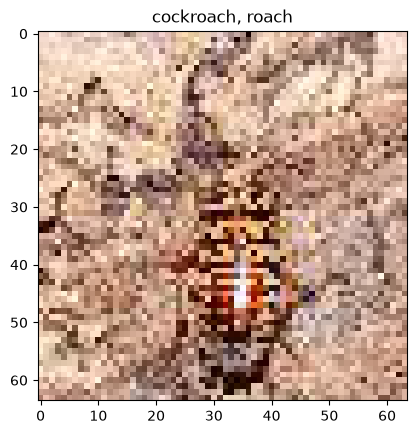

In [27]:
plt.imshow(X_train[1])
plt.title(idx_to_wordnet[y_train[1]])

Yeah.. we can see why even the best models struggle to cross lower than 18% error now ...

Yeah.. so i wanna see *Espresso*

In [28]:
(y_train == 8)

array([False, False, False, ..., False, False, False])

In [29]:
esp_idx = np.where([idx_to_wordnet[y] == 'espresso' for y in y_train])[0]

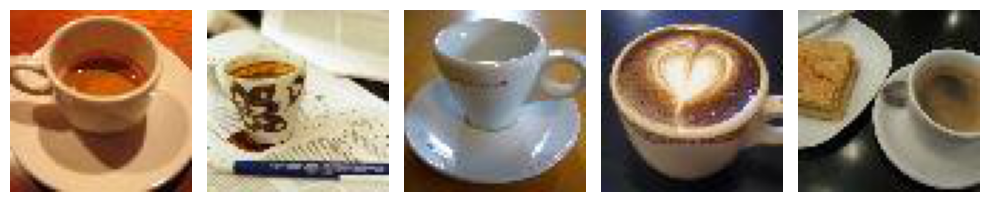

In [30]:
fig, axes= plt.subplots(1, 5, figsize= (10,15))
indices= np.random.choice(esp_idx, 5, replace= False)

for (i, ax) in zip(indices, axes.ravel()):
    ax.imshow(X_train[i])
    ax.axis("off")

plt.tight_layout()

Man.. most of these are'nt even Espresso.... I'm disappointed

Anyways.. let's just look at some images

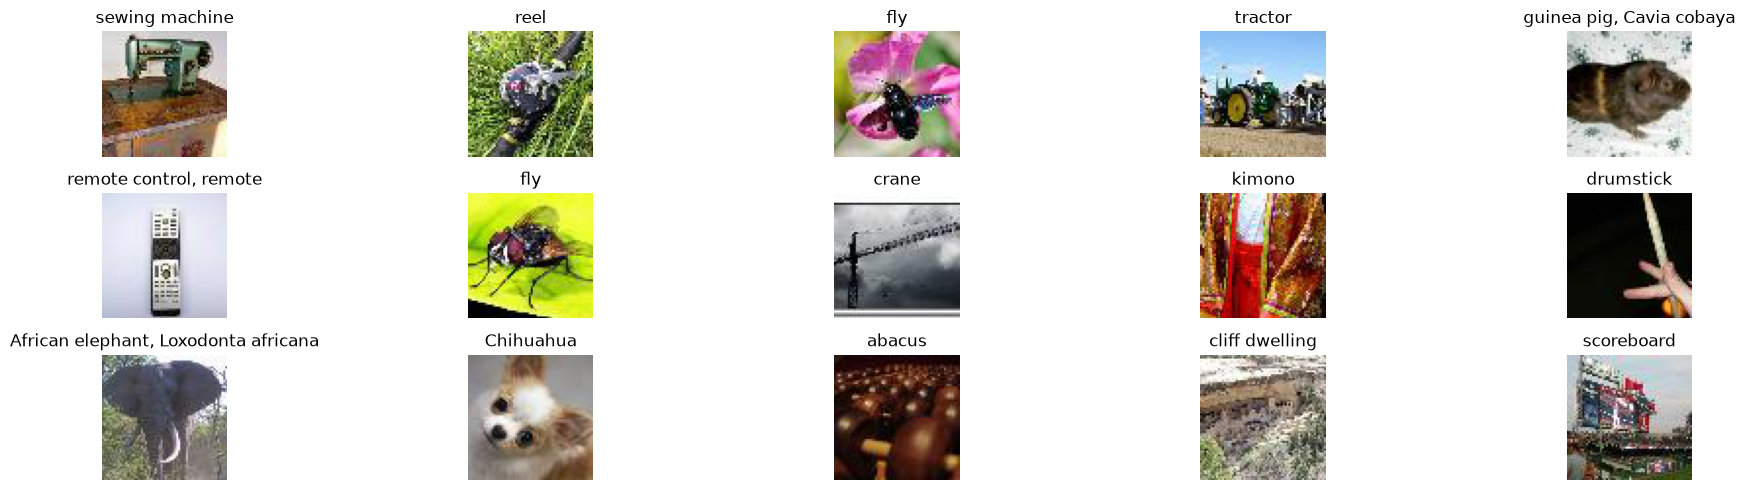

In [31]:
fig, axes= plt.subplots(3,5, figsize= (20,5))

indices= np.random.choice(90000, 15, replace= False)

for (i, ax) in zip(indices, axes.ravel()):
    ax.imshow(X_train[i])
    ax.set_title(idx_to_wordnet[y_train[i]])
    ax.axis("off")

plt.tight_layout()

Gotta get myself a "sombrero", huh

### Implementing AlexNet Architecture

Ok.. coming directly onto the good stuff.. here we go

In [32]:
X_train[1].shape

(64, 64, 3)

In [33]:
X_train[1][1][:5]

array([[245, 219, 206],
       [245, 219, 206],
       [251, 225, 212],
       [255, 229, 216],
       [240, 214, 201]], dtype=uint8)

Yeah... so as expected, gotta **Normalize** them

In [34]:
# AlexNet = tf.keras.Sequential([
#     tf.keras.layers.Resizing(227, 227, input_shape=(64, 64, 3)), #AlexNet uses 227 x 227 x 3 sized images
#     tf.keras.layers.Rescaling(1./255), # Normalization

#     #Layer1
#     tf.keras.layers.Conv2D(96, 11, 4, activation='relu'),
#     tf.keras.layers.MaxPooling2D(3, 2),

#     #Layer2
#     tf.keras.layers.Conv2D(256, 5, padding="same", activation='relu'),
#     tf.keras.layers.MaxPooling2D(3,2),

#     #Layers3-5
#     tf.keras.layers.Conv2D(384, 3, padding="same", activation='relu'),
#     tf.keras.layers.Conv2D(384, 3, padding="same", activation='relu'),
#     tf.keras.layers.Conv2D(256, 3, padding="same", activation='relu'),
    
#     tf.keras.layers.MaxPooling2D(3,2),
#     tf.keras.layers.Flatten(),

#     tf.keras.layers.Dense(2048, activation='relu'),
#     tf.keras.layers.Dense(1024, activation='relu'),
#     tf.keras.layers.Dense(200, activation= "softmax")
# ])

In [35]:
# AlexNet.summary()

In [36]:
# AlexNet.compile(
#     loss= ["sparse_categorical_crossentropy"], 
#     optimizer=tf.keras.optimizers.SGD(
#         learning_rate=0.01,
#         momentum=0.9
#     ),
#     metrics= ["accuracy"]
# )

In [37]:
# early_stop = tf.keras.callbacks.EarlyStopping(
#     monitor="val_accuracy",
#     mode="max",
#     patience=8,
#     restore_best_weights=True
# )

In [38]:
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


2026-09-12 08:55:08.334293: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-09-12 08:55:08.437756: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-09-12 08:55:08.437840: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.


In [39]:
# history = AlexNet.fit(
#     X_train, y_train,
#     validation_data=(X_valid, y_valid),
#     epochs=50,
#     batch_size=16,
#     validation_batch_size=16,
#     callbacks=[early_stop]
# )

Okay.. Phew, we managed to train a model on GPU then.. that's a milestone

Obv, model is shit for now, but that was to be expected.. with 90k images.. we expect convergence at around 70 epochs.. + We gotta add something

Next up, increase batch size and introduce dropout in the Fully Connected Layer

In [40]:
# AlexNet = tf.keras.Sequential([
#     tf.keras.layers.Resizing(227, 227, input_shape=(64, 64, 3)), #AlexNet uses 227 x 227 x 3 sized images
#     tf.keras.layers.Rescaling(1./255), # Normalization
#     #Layer1
#     tf.keras.layers.Conv2D(96, 11, 4, activation='relu'),
#     tf.keras.layers.MaxPooling2D(3, 2),
#     #Layer2
#     tf.keras.layers.Conv2D(256, 5, padding="same", activation='relu'),
#     tf.keras.layers.MaxPooling2D(3,2),

#     #Layers3-5
#     tf.keras.layers.Conv2D(384, 3, padding="same", activation='relu'),
#     tf.keras.layers.Conv2D(384, 3, padding="same", activation='relu'),
#     tf.keras.layers.Conv2D(256, 3, padding="same", activation='relu'),
    
#     tf.keras.layers.MaxPooling2D(3,2),
#     tf.keras.layers.Flatten(),

#     tf.keras.layers.Dense(2048, activation='relu'),
#     tf.keras.layers.Dropout(0.5), 
#     tf.keras.layers.Dense(1024, activation='relu'),
#     tf.keras.layers.Dropout(0.5),
#     tf.keras.layers.Dense(200, activation= "softmax")
# ])

In [41]:
# AlexNet.compile(
#     loss= ["sparse_categorical_crossentropy"], 
#     optimizer=tf.keras.optimizers.SGD(
#         learning_rate=0.01,
#         momentum=0.9
#     ),
#     metrics= ["accuracy"]
# )

In [42]:
# early_stop = tf.keras.callbacks.EarlyStopping(
#     monitor="val_accuracy",
#     mode="max",
#     patience=8,
#     restore_best_weights=True
# )

In [43]:
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [44]:
# history = AlexNet.fit(
#     X_train, y_train,
#     validation_data=(X_valid, y_valid),
#     epochs=50,
#     batch_size=32,
#     validation_batch_size=32,
#     callbacks=[early_stop]
# )

In [45]:
# max(history.history['val_accuracy']) 

In [46]:
# min(history.history["val_loss"])

In [47]:
# import pickle

# with open("alexnet_history(introduced dropout).pkl", "wb") as f:
#     pickle.dump(history.history, f)

In [48]:
# history.history.keys()

In [49]:
## Freeing up our GPU so that we can go ahead and train the next model (modified).. 
##i think we need to add a Conv layer over here.. The drop towards the end is just way too high

Our best val accuracy with AlexNet was 0.188 and lowest val_loss was 3.72

In [50]:
# AlexNet2 = tf.keras.Sequential([
#     tf.keras.layers.Resizing(227, 227, input_shape=(64, 64, 3)), #AlexNet uses 227 x 227 x 3 sized images
#     tf.keras.layers.Rescaling(1./255), # Normalization
#     #Layer1
#     tf.keras.layers.Conv2D(96, 11, 4, activation='relu'),
#     tf.keras.layers.MaxPooling2D(3, 2),
#     #Layer2
#     tf.keras.layers.Conv2D(256, 5, padding="same", activation='relu'),
#     tf.keras.layers.MaxPooling2D(3,2),

#     #Layers3-5
#     tf.keras.layers.Conv2D(384, 3, padding="same", activation='relu'),
#     tf.keras.layers.Conv2D(256, 3, padding="same", activation='relu'),
#     tf.keras.layers.Conv2D(128, 3, padding="same", activation='relu'),
#     tf.keras.layers.Conv2D(128, 3, padding="same", activation='relu'),
    
#     tf.keras.layers.MaxPooling2D(3,2),
#     tf.keras.layers.Flatten(),

#     tf.keras.layers.Dense(2048, activation='relu'),
#     tf.keras.layers.Dropout(0.5), 
#     tf.keras.layers.Dense(1024, activation='relu'),
#     tf.keras.layers.Dropout(0.5),
#     tf.keras.layers.Dense(200, activation= "softmax")
# ])

In [51]:
# AlexNet2.compile(
#     loss= ["sparse_categorical_crossentropy"], 
#     optimizer=tf.keras.optimizers.SGD(
#         learning_rate=0.01,
#         momentum=0.9
#     ),
#     metrics= ["accuracy"]
# )

In [52]:
# history = AlexNet2.fit(
#     X_train, y_train,
#     validation_data=(X_valid, y_valid),
#     epochs=50,
#     batch_size=32,
#     validation_batch_size=32,
#     callbacks=[early_stop]
# )

In [53]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    mode="max",
    patience=8,
    restore_best_weights=True
)

In [54]:
lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=4,
    min_lr=1e-6,
    verbose=1
)

In [55]:
AlexNet3 = tf.keras.Sequential([
    tf.keras.layers.Resizing(227, 227, input_shape=(64, 64, 3)), #AlexNet uses 227 x 227 x 3 sized images
    tf.keras.layers.Rescaling(1./255), # Normalization
    #Layer1
    tf.keras.layers.Conv2D(96, 11, 4, activation='relu'),
    tf.keras.layers.MaxPooling2D(3, 2),
    #Layer2
    tf.keras.layers.Conv2D(256, 5, padding="same", activation='relu'),
    tf.keras.layers.MaxPooling2D(3,2),

    #Layers3-5
    tf.keras.layers.Conv2D(384, 3, padding="same", activation='relu'),
    tf.keras.layers.Conv2D(256, 3, padding="same", activation='relu'),
    tf.keras.layers.Conv2D(128, 3, padding="same", activation='relu'),
    
    tf.keras.layers.MaxPooling2D(3,2),
    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(2048, activation='relu'),
    tf.keras.layers.Dropout(0.5), 
    tf.keras.layers.Dense(2048, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(200, activation= "softmax")
])

2026-09-12 08:55:08.935180: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-09-12 08:55:08.935279: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-09-12 08:55:08.935322: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-09-12 08:55:09.127429: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-09-12 08:55:09.127501: I external/local_xla/xla/stream_executor

In [56]:
AlexNet3.compile(
    loss= ["sparse_categorical_crossentropy"], 
    optimizer=tf.keras.optimizers.SGD(
        learning_rate=0.01,
        momentum=0.9
    ),
    metrics= ["accuracy"]
)

In [57]:
history = AlexNet3.fit(
    X_train, y_train,
    validation_data=(X_valid, y_valid),
    epochs=50,
    batch_size=32,
    validation_batch_size=32,
    callbacks=[early_stop, lr_scheduler]
)

2026-09-12 08:55:10.261616: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 1105920000 exceeds 10% of free system memory.
2026-09-12 08:55:12.468837: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 1105920000 exceeds 10% of free system memory.


Epoch 1/50


2026-09-12 08:55:14.023711: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8904
2026-09-12 08:55:14.198753: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2026-09-12 08:55:14.903629: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2026-09-12 08:55:15.497104: I external/local_xla/xla/service/service.cc:168] XLA service 0x73c408901ee0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-09-12 08:55:15.497195: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce RTX 2050, Compute Capability 8.6
I0000 00:00:1789203315.568649    6575 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


2813/2813 [==============================] - 136s 46ms/step - loss: 5.2878 - accuracy: 0.0057 - val_loss: 5.2057 - val_accuracy: 0.0121 - lr: 0.0100
Epoch 2/50
2813/2813 [==============================] - 142s 50ms/step - loss: 5.0525 - accuracy: 0.0214 - val_loss: 4.7905 - val_accuracy: 0.0391 - lr: 0.0100
Epoch 3/50
2813/2813 [==============================] - 136s 48ms/step - loss: 4.6780 - accuracy: 0.0526 - val_loss: 4.4539 - val_accuracy: 0.0764 - lr: 0.0100
Epoch 4/50
2813/2813 [==============================] - 139s 49ms/step - loss: 4.3780 - accuracy: 0.0880 - val_loss: 4.1134 - val_accuracy: 0.1244 - lr: 0.0100
Epoch 5/50
2813/2813 [==============================] - 141s 50ms/step - loss: 4.1235 - accuracy: 0.1210 - val_loss: 3.9866 - val_accuracy: 0.1478 - lr: 0.0100
Epoch 6/50
2813/2813 [==============================] - 141s 50ms/step - loss: 3.9556 - accuracy: 0.1451 - val_loss: 3.8507 - val_accuracy: 0.1703 - lr: 0.0100
Epoch 7/50
2813/2813 [=============================

KeyboardInterrupt: 

In [61]:
AlexNet3.history.history

{'loss': [5.287792205810547,
  5.052511692047119,
  4.678046226501465,
  4.377995014190674,
  4.123462677001953,
  3.9555583000183105,
  3.836134433746338,
  3.749605894088745,
  3.7153210639953613,
  3.6966540813446045,
  3.7145636081695557,
  3.712769031524658,
  3.7700273990631104,
  3.8212757110595703,
  3.312124729156494,
  3.034808397293091,
  2.8503715991973877,
  2.6916959285736084,
  2.553290367126465,
  2.416410446166992,
  2.284855842590332,
  2.1525259017944336,
  2.026854991912842,
  1.9050904512405396,
  1.795522689819336,
  1.4646612405776978,
  1.3619577884674072,
  1.298208475112915,
  1.2428700923919678,
  1.1702649593353271,
  1.1448898315429688,
  1.129760503768921,
  1.1197482347488403],
 'accuracy': [0.00567777780815959,
  0.021388888359069824,
  0.05258888751268387,
  0.08803333342075348,
  0.12101110816001892,
  0.14505556225776672,
  0.16339999437332153,
  0.17773333191871643,
  0.18382222950458527,
  0.18805555999279022,
  0.18496666848659515,
  0.186344444751

In [62]:
import pickle

with open("AlexNet3_history.pkl", "wb") as f:
    pickle.dump(AlexNet3.history.history, f)

In [67]:
h = AlexNet3.history.history

best_epoch = h["val_accuracy"].index(max(h["val_accuracy"])) + 1

print("Best epoch:", best_epoch)
print("Best validation accuracy:", max(h["val_accuracy"]))
print("Best validation loss:", h["val_loss"][best_epoch -1 ])

Best epoch: 33
Best validation accuracy: 0.2921000123023987
Best validation loss: 3.449446439743042


In [70]:
print("Best val accuracy: ", max(AlexNet3.history.history["val_accuracy"]))
print("Best validation loss: ", min(AlexNet3.history.history["val_loss"]))

Best val accuracy:  0.2921000123023987
Best validation loss:  3.2220370769500732


So next time we gotta beat 0.29 val accuracy and 3.22 Val Loss

The original AlexNet has a 34% error rate in their 'top-1' error and they had 2 4096 FCLayers at the end.. We can't afford that with our GPU so a 70% error rate right now doesn't look too bad